<html> <h1 style="font-style:bold; color:blue;"> Neural Computing and Deep Learning </h1> </html>

<html> <h1 style="font-style:italic; color:blue;"> Week-12 </h1> </html>

<html> <h2 style="font-style:italic; color:blue;"> Attention Networks </21> </html>

The tutorial will cover the following:

* Preparing a simple dataset for time series forecasting
* How to use a network built via SimpleRNN for time series forecasting
* Adding a custom attention layer to the SimpleRNN network

_________![image.png](attachment:0ad58c9b-2c05-4e8f-b456-56365c0e007f.png)

In [1]:
from pandas import read_csv
import numpy as np

import tensorflow as tf
from tensorflow import keras

from keras import Model
from tensorflow.keras.layers import Layer
from keras.layers import Input, Dense, SimpleRNN

from sklearn.preprocessing import MinMaxScaler

from keras.models import Sequential
from keras.metrics import mean_squared_error

print(tf.__version__)

2.20.0


### The Dataset

We will create a fibonacci sequence dataset for our purpose. In Fibonacci sequence, one number is constructed from the previous two numbers. The first 10 numbers of the sequence are shown below:

0, 1, 1, 2, 3, 5, 8, 13, 21, 34, …


When given the previous ‘t’ numbers, can you get a machine to accurately reconstruct the next number? This would mean discarding all the previous inputs except the last two and performing the correct operation on the last two numbers.

For this tutorial, you’ll construct the training examples from t time steps and use the value at t+1 as the target. For example, if t=3, then the training examples and the corresponding target values would look as follows:


![image.png](attachment:image.png)

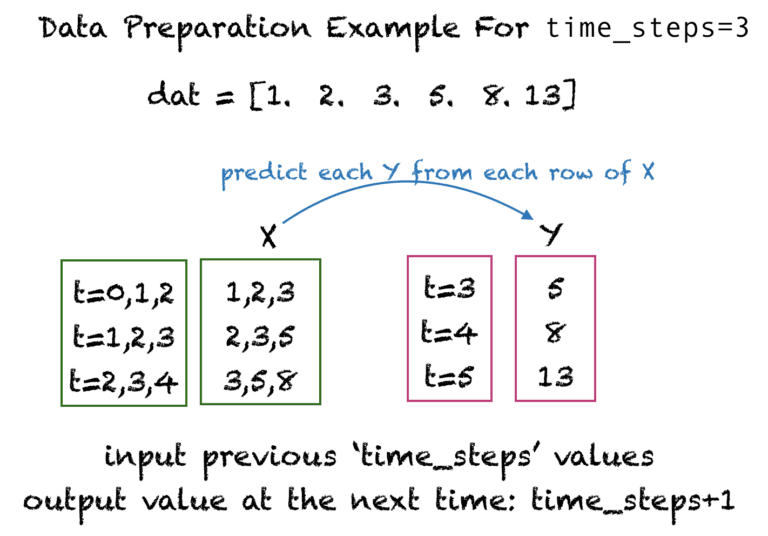

![image.png](attachment:image.png)

The Fibonacci spiral: an approximation of the **golden spiral** created by drawing circular arcs connecting the opposite corners of squares in the Fibonacci tiling

### Data preprocessing

_____________________![image.png](attachment:8d917c7c-28cf-41b6-8242-3dc62a9d37f5.png)

In [2]:
def get_fib_seq(n, scale_data=True):

    seq = np.zeros(n)
    fib_n1 = 0.0
    fib_n = 1.0

    for i in range(n):
        seq[i] = fib_n1 + fib_n
        fib_n1 = fib_n
        fib_n = seq[i]

    scaler = []
    if scale_data:
        scaler = MinMaxScaler(feature_range=(0, 1))
        seq = np.reshape(seq, (n, 1))
        seq = scaler.fit_transform(seq).flatten()

    return seq, scaler

#### Hint:

You can copy blocks of code in the cells above and cells from previous weeks of practice sessions.

Some are easy enough to copy, some need to be slightly modified. This can speed up your code creation.

In [3]:
# Check if the function works correctly:
# Copy the previous cell, change the function name and add fib_n

________________________![image.png](attachment:18cddcac-477d-4e87-8b99-6dcacd5036d9.png)

In [4]:
def get_fib_seq_check(n, scale_data=True):

    seq = np.zeros(n)
    fib_n1 = 0.0
    fib_n = 1.0

    for i in range(n):
        seq[i] = fib_n1 + fib_n
        fib_n1 = fib_n
        fib_n = seq[i]

    scaler = []
    if scale_data:
        scaler = MinMaxScaler(feature_range=(0, 1))
        seq = np.reshape(seq, (n, 1))
        seq = scaler.fit_transform(seq).flatten()

    return seq, scaler, fib_n

_________________![image.png](attachment:db321006-92cc-4c45-9708-928ab15601de.png)

In [5]:
n = 4
dat, scaler, fib_N = get_fib_seq_check(n)
print('seq_normalised =', dat, '\n')
print('seq =', dat*(fib_N-1)+1)

seq_normalised = [0.   0.25 0.5  1.  ] 

seq = [1. 2. 3. 5.]


In [6]:
# Your code for the same checking with n=6

#
#
#


In [7]:
n = 6
dat, scaler, fib_N = get_fib_seq_check(n)
print('seq_normalised =', dat, '\n')
print('seq =', dat*(fib_N-1)+1)

seq_normalised = [0.         0.08333333 0.16666667 0.33333333 0.58333333 1.        ] 

seq = [ 1.  2.  3.  5.  8. 13.]


In [8]:
# Your code for the same checking with n=8

#
#
#

seq_normalised = [0.         0.03030303 0.06060606 0.12121212 0.21212121 0.36363636
 0.60606061 1.        ] 
seq            = [ 1.  2.  3.  5.  8. 13. 21. 34.]


In [ ]:
# Your code for the same checking with n=10

#
#
#

In [9]:
n = 8
dat, scaler, fib_N = get_fib_seq_check(n)
print('seq_normalised =', dat, '\n')
print('seq =', dat*(fib_N-1)+1)

seq_normalised = [0.         0.03030303 0.06060606 0.12121212 0.21212121 0.36363636
 0.60606061 1.        ] 

seq = [ 1.  2.  3.  5.  8. 13. 21. 34.]


___________________![image.png](attachment:7e618c91-f0e5-4de1-ba94-a64fa41371ef.png)

In [10]:
n = 10
dat, scaler, fib_N = get_fib_seq_check(n)
print('seq_normalised =', dat, '\n')
print('seq =', dat*(fib_N-1)+1)

seq_normalised = [0.         0.01136364 0.02272727 0.04545455 0.07954545 0.13636364
 0.22727273 0.375      0.61363636 1.        ] 

seq = [ 1.  2.  3.  5.  8. 13. 21. 34. 55. 89.]


In [11]:
scaler

MinMaxScaler()

### The following function transforms the fibonacci sequence into training and test dataset.

X and Y looks like the following. From X and Y, we create training and test dataset.


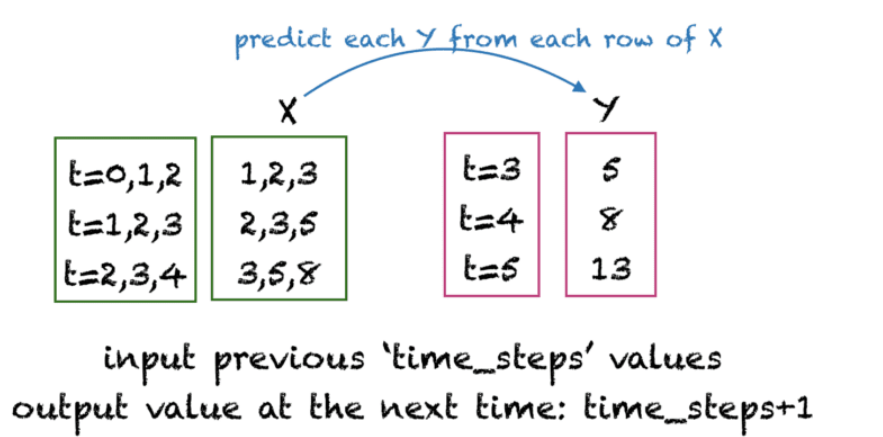

____________________![image.png](attachment:4c5f5581-f82f-4df3-9a8f-e565740db8f3.png)

In [12]:
def get_fib_XY(total_fib_numbers, time_steps, train_percent, scale_data=True):

    dat, scaler = get_fib_seq(total_fib_numbers, scale_data)

    Y_ind = np.arange(time_steps, len(dat), 1)
    Y = dat[Y_ind]
    rows_x = len(Y)

    X = dat[0:rows_x]

    for i in range(time_steps-1):
        temp = dat[i+1:rows_x+i+1]
        X = np.column_stack((X, temp))

    rand = np.random.RandomState(seed=13)
    idx = rand.permutation(rows_x)

    split = int(train_percent * rows_x)

    train_ind = idx[0:split]
    test_ind = idx[split:]

    trainX = X[train_ind]
    trainY = Y[train_ind]

    testX = X[test_ind]
    testY = Y[test_ind]

    trainX = np.reshape(trainX, (len(trainX), time_steps, 1))
    testX = np.reshape(testX, (len(testX), time_steps, 1))

    return trainX, trainY, testX, testY, scaler

_________________![image.png](attachment:f6c95298-4108-4f3d-a7bd-b411e900a952.png)

In [13]:
get_fib_XY(8, 3, 0.8)

(array([[[0.03030303],
         [0.06060606],
         [0.12121212]],
 
        [[0.12121212],
         [0.21212121],
         [0.36363636]],
 
        [[0.21212121],
         [0.36363636],
         [0.60606061]],
 
        [[0.        ],
         [0.03030303],
         [0.06060606]]]),
 array([0.21212121, 0.60606061, 1.        , 0.12121212]),
 array([[[0.06060606],
         [0.12121212],
         [0.21212121]]]),
 array([0.36363636]),
 MinMaxScaler())

In [14]:
#np.column_stack?

In [ ]:
#np.random.RandomState.permutation?

### In the following code, we test the performance with the help of a simple RNN.


#### Set up parameters

__________________![image.png](attachment:2c3fc454-be8a-44bc-bddd-bf159366d371.png)

In [15]:
time_steps = 20
hidden_units = 4
epochs = 51

#### Create a traditional RNN network

______________![image.png](attachment:b88e1fbb-1de4-4825-9870-7ee60b591bff.png)

In [16]:
def create_RNN(hidden_units, dense_units, input_shape, activation):

    model = Sequential()
    model.add(SimpleRNN(hidden_units, input_shape=input_shape, activation=activation[0]))
    model.add(Dense(units=dense_units, activation=activation[1]))
    model.compile(loss='mse', optimizer='adam')

    return model

___________________![image.png](attachment:3ca4d694-faeb-4cbf-9058-81ad2750ce9a.png)

In [17]:
model_RNN = create_RNN(
    hidden_units=hidden_units,
    dense_units=1,
    input_shape=(time_steps, 1),
    activation=['tanh', 'tanh']
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


![image.png](attachment:87ecc6c6-cdc0-4f5f-9fbf-9d5f1d482525.png)

##### tf.keras.activations.tanh

https://www.tensorflow.org/api_docs/python/tf/keras/activations/tanh

In [18]:
# Your code to print the model summary

#
#

In [19]:
model_RNN.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 4)              │            24 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29 (116.00 B)

 Trainable params: 29 (116.00 B)

 Non-trainable params: 0 (0.00 B)

________________________![image.png](attachment:6def3a3d-1d23-428e-bfdc-599c05882d55.png)

In [20]:
trainX, trainY, testX, testY, scaler = get_fib_XY(1200, time_steps, 0.7)

#### Train the network

_____________________![image.png](attachment:fdf0c280-b340-494d-a303-7662c76ee97c.png)

In [21]:
history = model_RNN.fit(trainX, trainY, epochs=epochs, batch_size=1, verbose=1)

Epoch 1/51
826/826 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.0024    
Epoch 2/51
826/826 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0022
Epoch 3/51
826/826 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0020    
Epoch 4/51
826/826 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0017
Epoch 5/51
826/826 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0015    
Epoch 6/51
826/826 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0013
Epoch 7/51
826/826 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.0011    
Epoch 8/51
826/826 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 9.5886e-04
Epoch 9/51
826/826 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 7.9498e-04
Epoch 10/51
826/826 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 6.4256e-04
Epoch 11/51
826/826 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 4.8748e-04
Epoch 12/51
826/826 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 3.6293e-04
Epoch 13/51
826/826 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 2.5546e-04
Epoch 14/51
826/826 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 1.6310e-04
Epoch 15/51
8

____________________![image.png](attachment:63ee9395-7301-4020-8459-f18c59469e89.png)

In [22]:
import matplotlib.pyplot as plt
%matplotlib inline

#### Hint:

You can copy blocks of code in the cells above and cells from previous weeks of practice sessions.

Some are easy enough to copy, some need to be slightly modified. This can speed up your code creation.

___________________![image.png](attachment:0906917e-d0bd-4f2f-b06b-3ab1a64df7d0.png)

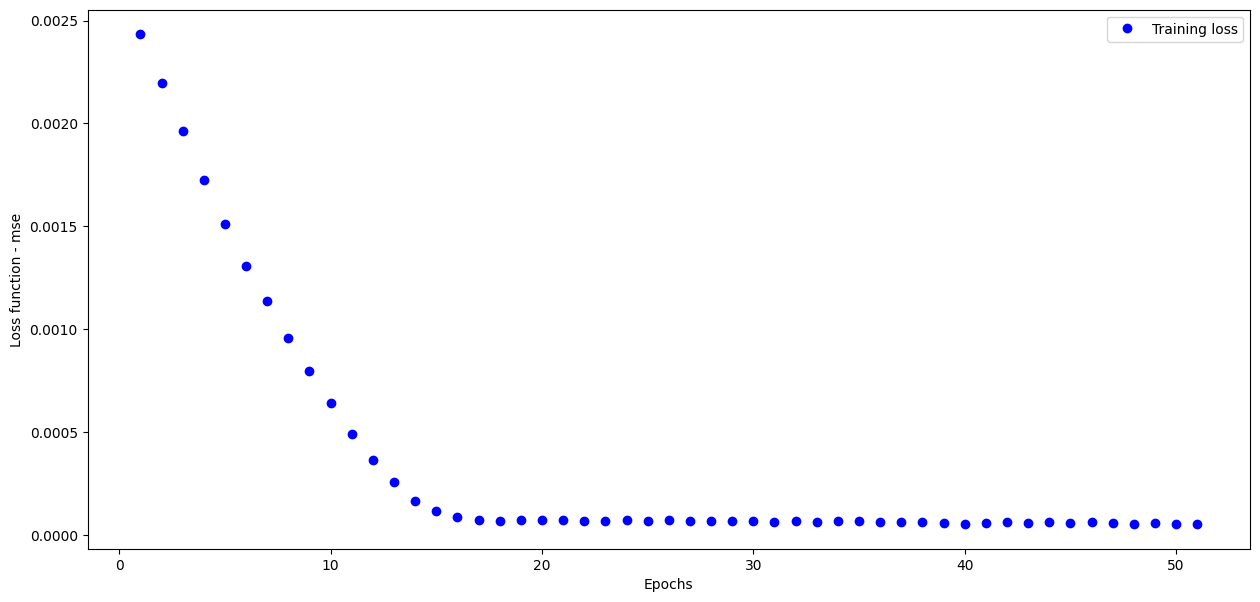

In [23]:
history_dict = history.history

losses = history_dict['loss']
Epochs = range(1, len(losses) + 1)

plt.figure(num=1, figsize=(15,7))
plt.plot(Epochs, losses, 'bo', label='Training loss')

plt.xlabel('Epochs')
plt.ylabel('Loss function - mse')
plt.legend()
plt.show()

#### Evalute model

____________________![image.png](attachment:704c6239-7252-4312-bf39-7787d8022c14.png)

In [24]:
train_mse = model_RNN.evaluate(trainX, trainY)
test_mse = model_RNN.evaluate(testX, testY)

26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5.2575e-05  
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 3.7854e-05 


#### Print train and test error metrics

__________________![image.png](attachment:2ef16392-7c84-4b09-b6e0-3b3da59bfd22.png)

In [25]:
print("Train set MSE = ", train_mse)
print("Test set MSE = ", test_mse)

Train set MSE =  5.2575393056031317e-05
Test set MSE =  3.785439912462607e-05


### The following code creates an attention layer. You need to understand each line to know how an attention layer can be created.


_____________________![image.png](attachment:71d7c411-79dc-4192-88e6-9173000987a8.png)

In [26]:
@tf.keras.utils.register_keras_serializable()
class attention(Layer):

    def __init__(self, **kwargs):
        super(attention, self).__init__(**kwargs)

    def build(self, input_shape):
        self.W = self.add_weight(
            name='attention_weight',
            shape=(input_shape[-1], 1),
            initializer='random_normal',
            trainable=True
        )

        self.b = self.add_weight(
            name='attention_bias',
            shape=(input_shape[1], 1),
            initializer='zeros',
            trainable=True
        )

        super(attention, self).build(input_shape)

    def call(self, x):
        e = tf.tanh(tf.matmul(x, self.W) + self.b)
        e = tf.squeeze(e, axis=-1)
        alpha = tf.nn.softmax(e)
        alpha = tf.expand_dims(alpha, axis=-1)
        context = x * alpha
        context = tf.reduce_sum(context, axis=1)
        return context

    def compute_output_shape(self, input_shape):
        return (input_shape[0], input_shape[-1])

### The following code develops an RNN with an attention layer to predict the Fibonacci sequence.



________________________![image.png](attachment:6e69b52b-48d7-4659-be59-e8002755800c.png)

In [27]:
def create_RNN_with_attention(hidden_units, dense_units, input_shape, activation):

    x = Input(shape=input_shape)
    RNN_layer = SimpleRNN(hidden_units, return_sequences=True, activation=activation)(x)

    attention_layer = attention()(RNN_layer)

    outputs = Dense(dense_units, trainable=True, activation=activation)(attention_layer)

    model = Model(x, outputs)
    model.compile(loss='mse', optimizer='adam')

    return model

________________![image.png](attachment:bcd5cc9e-72bb-461e-bd3d-d31961d0c619.png)

In [28]:
model_attention = create_RNN_with_attention(
    hidden_units=hidden_units,
    dense_units=1,
    input_shape=(time_steps, 1),
    activation='tanh'
)

In [29]:
# Your code to print the model summary

#
#


In [30]:
model_attention.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 20, 1)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, 20, 4)          │            24 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ attention (attention)           │ (None, 4)              │            24 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 53 (212.00 B)

 Trainable params: 53 (212.00 B)

 Non-trainable params: 0 (0.00 B)

In [31]:
# Your code to fit the model
# save the results of the training to 'history_2' variable list
# use batch_size=1

#
#

In [32]:
history_2 = model_attention.fit(trainX, trainY, epochs=epochs, batch_size=1, verbose=1)

Epoch 1/51
826/826 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.0015
Epoch 2/51
826/826 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0015    
Epoch 3/51
826/826 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0015    
Epoch 4/51
826/826 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0014    
Epoch 5/51
826/826 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0014    
Epoch 6/51
826/826 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.0014    
Epoch 7/51
826/826 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0014    
Epoch 8/51
826/826 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0014    
Epoch 9/51
826/826 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0013
Epoch 10/51
826/826 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0013    
Epoch 11/51
826/826 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0013    
Epoch 12/51
826/826 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0012
Epoch 13/51
826/826 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0011
Epoch 14/51
826/826 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0011    
Epoch 15/51
826/8

#### Hint:

You can copy blocks of code in the cells above and cells from previous weeks of practice sessions.

Some are easy enough to copy, some need to be slightly modified. This can speed up your code creation.


_______________________![image.png](attachment:1b1f1396-b1ab-4e3f-9305-97926a7f8442.png)

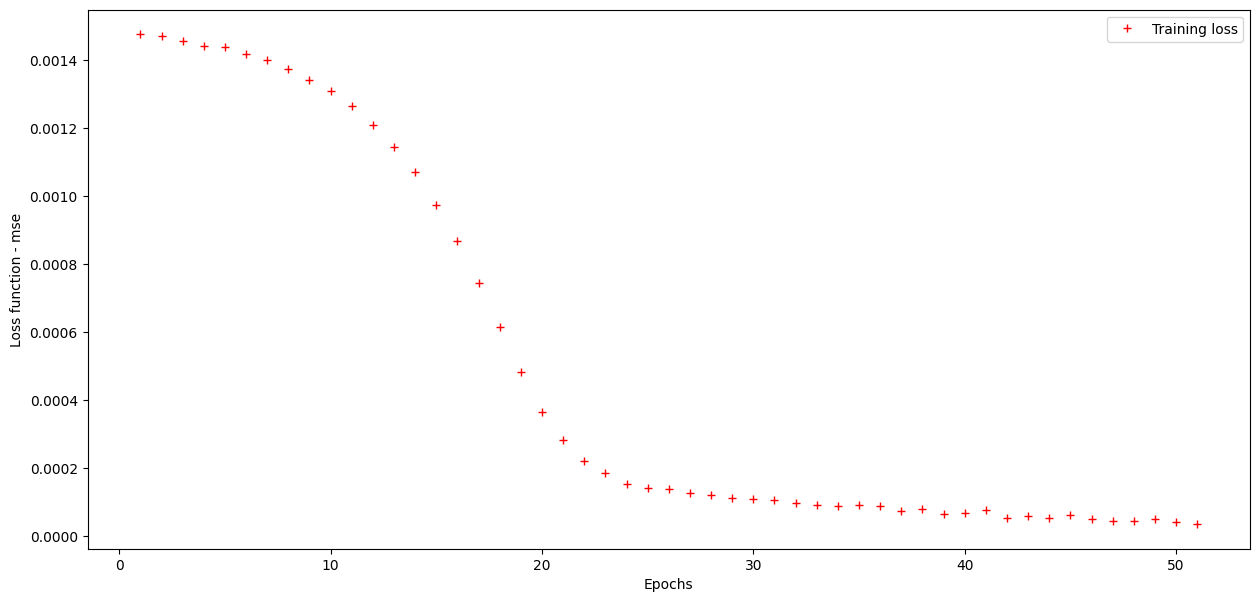

In [33]:
history_dict = history_2.history

losses = history_dict['loss']
Epochs = range(1, len(losses) + 1)

plt.figure(num=1, figsize=(15,7))
plt.plot(Epochs, losses, 'r+', label='Training loss')

plt.xlabel('Epochs')
plt.ylabel('Loss function - mse')
plt.legend()
plt.show()

In [34]:
# Your code to Evaluate attention model on training set
# Your code to evaluate the attention model on the test set

# train_mse_attn =
# test_mse_attn =


In [35]:
train_mse_attn = model_attention.evaluate(trainX, trainY)
test_mse_attn = model_attention.evaluate(testX, testY)

26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 2.6035e-05  
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.8438e-05 


In [36]:
# Your code to print train error metric
# Your code to print test error metric

#
#

In [37]:
print("Train set MSE with attention = ", train_mse_attn)
print("Test set MSE with attention = ", test_mse_attn)

Train set MSE with attention =  2.6035406335722655e-05
Test set MSE with attention =  1.8437531252857298e-05


In [38]:
# Draw both loss functions' graphs together

________________________![image.png](attachment:74fcb146-ece0-40d3-8da7-5fe505256c97.png)

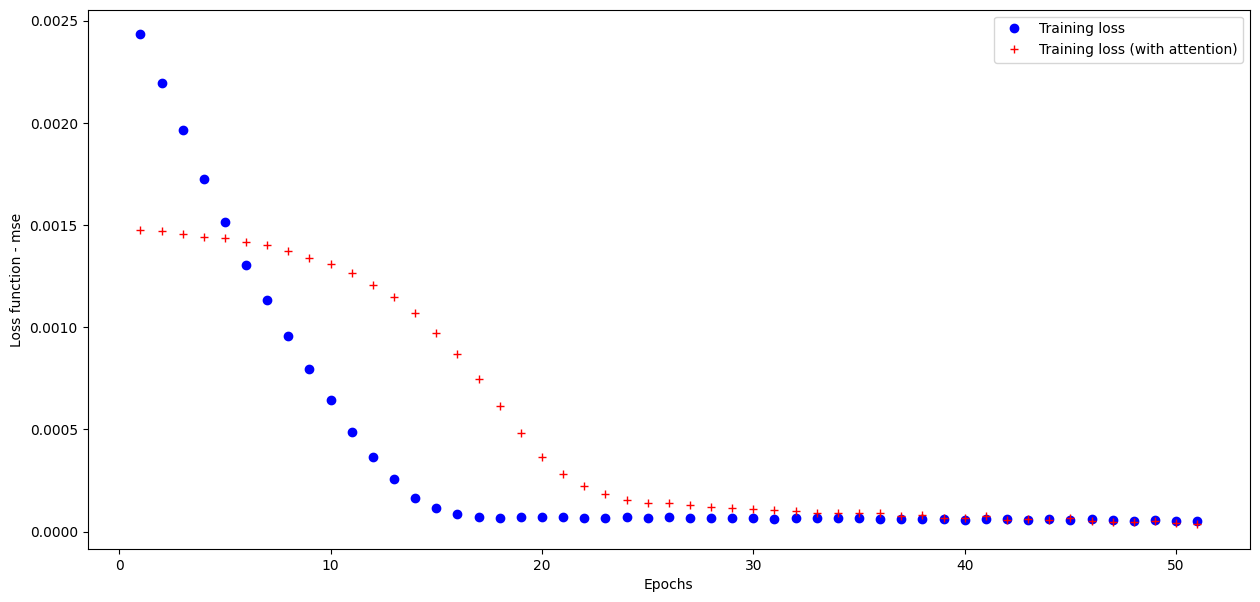

In [39]:
history_dict_1 = history.history
history_dict_2 = history_2.history

losses_1 = history_dict_1['loss']
losses_2 = history_dict_2['loss']

Epochs_1 = range(1, len(losses_1) + 1)
Epochs_2 = range(1, len(losses_2) + 1)

plt.figure(num=1, figsize=(15,7))

plt.plot(Epochs_1, losses_1, 'bo', label='Training loss')
plt.plot(Epochs_2, losses_2, 'r+', label='Training loss (with attention)')

plt.xlabel('Epochs')
plt.ylabel('Loss function - mse')
plt.legend()
plt.show()

### Plot the train and test MSE performance for the 'Simple RNN' and 'RNN with an attention layer'.


_________________![image.png](attachment:83d9133a-4654-451e-9f28-f0b7c028c16e.png)

In [40]:
import pandas as pd

_______________________![image.png](attachment:b72b208e-2e1b-41a3-9588-ac2a8cc4c0b5.png)

In [41]:
ErrorMetrics = [
    [train_mse, test_mse],
    [train_mse_attn, test_mse_attn]
]

ErrorMetrics

[[5.2575393056031317e-05, 3.785439912462607e-05],
 [2.6035406335722655e-05, 1.8437531252857298e-05]]

____________![image.png](attachment:ccfec9cf-53db-49be-a7df-d1f1bd9283bc.png)

In [42]:
ErrorMetrics_pd = pd.DataFrame(ErrorMetrics)
ErrorMetrics_pd.columns = ['Train', 'Test']
ErrorMetrics_pd.index = ['Simple RNN', 'RNN with an attention layer']
ErrorMetrics_pd

,Train,Test
Simple RNN,0.000053,0.000038
RNN with an attention layer,0.000026,0.000018


In [43]:
## MSE performance histogram

__________________![image.png](attachment:829c3328-45a7-483c-bf5a-2def8578093f.png)

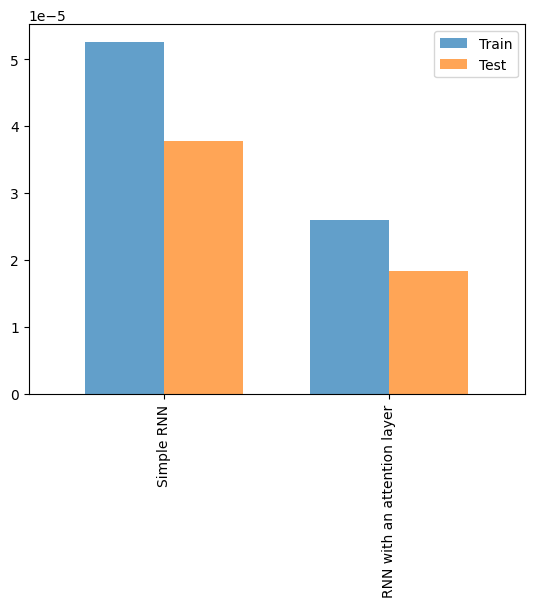

In [44]:
ErrorMetrics_pd.plot.bar(width=0.7, alpha=0.7)
plt.show()

# Lab Logbook Requirement:

<html> <h3 style="; color:blue;">

1) Modify the training parameter of the RNN with an attention layer model using the following formulas:

Modify the number of epochs:
Z + 50
, where your SID is: XXXXXXZ

Use EarlyStopping() and ModelCheckpoint() function to save the best modetl in the file 'best_attention_model.keras'
Modify the patience parameter:
Z + 10
, where your SID is: XXXXXXZ

2) Modify time_steps = 20 and hidden_units = 4
3) Leave other parameters the same as in the practical session
4) Calculate and demonstrate the received loss for train and test datasets
5) Plot the Loss function (MSE) graph during the training process for the 3 models together
6) Please only add to your Lab Logbook print-screens of:
- calculation of your parameters
- your code of using EarlyStopping() and ModelCheckpoint() functions
- your code and training result using model.fit()
- received loss for train and test datasets
- Loss (MSE) graph for the 3 models together during the training process
- performance histogram for train and test loss (MSE) of the 3 models together


</h3> </html>


<html> <h3 style="color:red;">
NOTE: DON'T FORGET TO SAVE AND BACK UP YOUR COMPLETED JUPYTER NOTEBOOK AND LAB LOGBOOK ON GITHUB.
</h3> </html>

### Test the above model with different parameters, layer size, train and test ratio, and time steps.



__________________![image.png](attachment:f0dddc48-9aa3-4770-aaaf-eba0a9b046a7.png)

In [45]:
# Import EarlyStopping and ModelCheckpoint
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.callbacks import ModelCheckpoint

In [46]:
# Modify parameters using SID (Z = 1)
Z = 1

time_steps = 20  # fixed as per requirement
hidden_units = 4  # fixed as per requirement

epochs = Z + 50  # 51
patience = Z + 10  # 11

print("epochs =", epochs)
print("patience =", patience)
print("time_steps =", time_steps)
print("hidden_units =", hidden_units)

epochs = 51
patience = 11
time_steps = 20
hidden_units = 4


In [ ]:
# Continue your code according to the Lab Logbook Requirements ...


In [47]:
# Prepare dataset using modified time_steps
trainX, trainY, testX, testY, scaler = get_fib_XY(1200, time_steps, 0.7)

In [48]:
# Define EarlyStopping and ModelCheckpoint
early_stop = EarlyStopping(
    monitor='loss',
    mode='min',
    patience=patience,
    verbose=1,
    restore_best_weights=True
)

model_ckpt = ModelCheckpoint(
    'best_attention_model.keras',
    monitor='loss',
    mode='min',
    verbose=1,
    save_best_only=True
)

In [49]:
# Create RNN with attention model
model_attention_new = create_RNN_with_attention(
    hidden_units=hidden_units,
    dense_units=1,
    input_shape=(time_steps, 1),
    activation='tanh'
)

In [50]:
# Train model using modified parameters and callbacks
history_new = model_attention_new.fit(
    trainX,
    trainY,
    epochs=epochs,
    batch_size=1,
    verbose=1,
    callbacks=[early_stop, model_ckpt]
)

Epoch 1/51
814/826 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0029
Epoch 1: loss improved from None to 0.00129, saving model to best_attention_model.keras

Epoch 1: finished saving model to best_attention_model.keras
826/826 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.0013
Epoch 2/51
820/826 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5.8105e-04
Epoch 2: loss improved from 0.00129 to 0.00123, saving model to best_attention_model.keras

Epoch 2: finished saving model to best_attention_model.keras
826/826 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0012    
Epoch 3/51
819/826 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.6014e-04
Epoch 3: loss improved from 0.00123 to 0.00112, saving model to best_attention_model.keras

Epoch 3: finished saving model to best_attention_model.keras
826/826 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0011    
Epoch 4/51
812/826 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 4.7533e-04
Epoch 4: loss improved from 0.00112 to 0.00101, saving model to best_attention_model.ker

In [51]:
# Load best saved model
Best_attention_model = keras.models.load_model(
    'best_attention_model.keras',
    custom_objects={'attention': attention}
)

In [52]:
# Evaluate train and test MSE
train_mse_new = Best_attention_model.evaluate(trainX, trainY)
test_mse_new = Best_attention_model.evaluate(testX, testY)

print("Train set MSE =", train_mse_new)
print("Test set MSE =", test_mse_new)

26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.9719e-05  
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 5.0560e-05 
Train set MSE = 1.971872006834019e-05
Test set MSE = 5.0559581723064184e-05


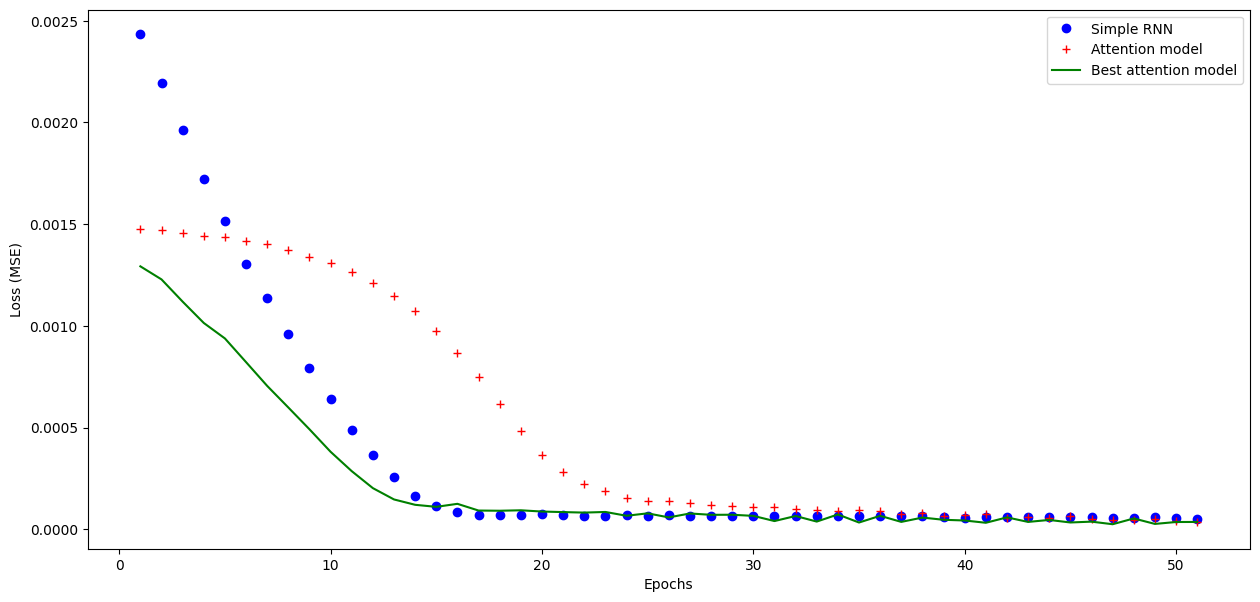

In [53]:
# Plot loss for 3 models
history_dict_1 = history.history
history_dict_2 = history_2.history
history_dict_3 = history_new.history

losses_1 = history_dict_1['loss']
losses_2 = history_dict_2['loss']
losses_3 = history_dict_3['loss']

epochs_1 = range(1, len(losses_1)+1)
epochs_2 = range(1, len(losses_2)+1)
epochs_3 = range(1, len(losses_3)+1)

plt.figure(figsize=(15,7))

plt.plot(epochs_1, losses_1, 'bo', label='Simple RNN')
plt.plot(epochs_2, losses_2, 'r+', label='Attention model')
plt.plot(epochs_3, losses_3, 'g-', label='Best attention model')

plt.xlabel('Epochs')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.show()

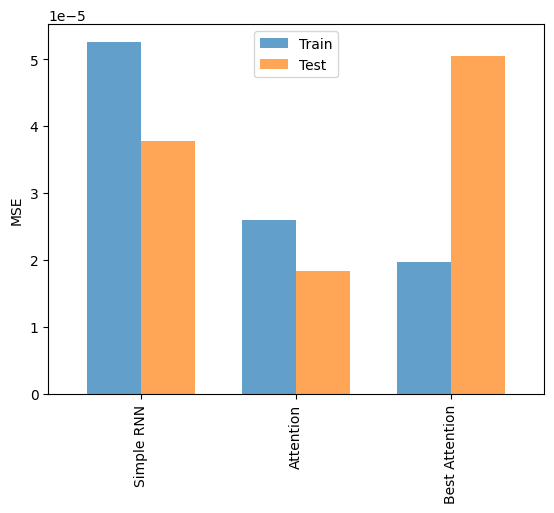

In [55]:
# Create histogram for performance comparison
import pandas as pd

ErrorMetrics = [
    [train_mse, test_mse],                  # Simple RNN
    [train_mse_attn, test_mse_attn],        # Attention model
    [train_mse_new, test_mse_new]           # Best attention model
]

ErrorMetrics_pd = pd.DataFrame(ErrorMetrics)
ErrorMetrics_pd.columns = ['Train', 'Test']
ErrorMetrics_pd.index = ['Simple RNN', 'Attention', 'Best Attention']

ErrorMetrics_pd.plot.bar(width=0.7, alpha=0.7)
plt.ylabel('MSE')
plt.show()